# Análise Exploratória de Dados

Este notebook é dedicado somente à **Análise Exploratória de Dados (EDA)** do dataset **20 Fonts Classification**. A ideia é entender os dados antes da modelagem: quantidade de imagens, classes, balanceamento, formato dos arquivos, tamanho das palavras e exemplos visuais.

Ao longo do notebook, cada resultado é acompanhado de uma discussão para explicar o que ele significa e como influencia as próximas etapas do trabalho.

## 1. Configuração do ambiente

A célula abaixo localiza automaticamente a raiz do projeto. Isso evita erro de importação quando o Jupyter é aberto diretamente dentro da pasta `notebooks/`.

In [1]:
from collections import Counter
from pathlib import Path
import sys

# Encontra a raiz do projeto procurando pelo script principal.
ROOT = Path.cwd()
while not (ROOT / "src" / "font_classification.py").exists():
    if ROOT.parent == ROOT:
        raise FileNotFoundError("Não encontrei src/font_classification.py. Abra o notebook dentro do projeto.")
    ROOT = ROOT.parent

sys.path.insert(0, str(ROOT / "src"))

PROJECT_PYTHON = ROOT / ".venv" / ("Scripts/python.exe" if sys.platform.startswith("win") else "bin/python")

def require_module(module_name, package_name=None):
    package_name = package_name or module_name
    try:
        __import__(module_name)
    except ModuleNotFoundError as exc:
        raise ModuleNotFoundError(
            f"O pacote '{package_name}' não está instalado no kernel atual.\n"
            f"Kernel atual: {sys.executable}\n"
            f"Ambiente do projeto esperado: {PROJECT_PYTHON}\n"
            "Selecione o kernel 'Python (.venv trabalho-redes-neurais)' ou instale as dependências no kernel atual com:\n"
            f"  {sys.executable} -m pip install -r \"{ROOT / 'requirements.txt'}\"\n"
            "Depois reinicie o kernel e execute o notebook desde o início."
        ) from exc

require_module("matplotlib")
require_module("pandas")
require_module("IPython")
require_module("PIL", "pillow")

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from PIL import Image
from data_utils import load_metadata

DATASET_DIR = ROOT / "dataset" / "20_fonts_classification"
FILES_DIR = DATASET_DIR / "files"

print(f"Raiz do projeto: {ROOT}")
print(f"Dataset: {DATASET_DIR}")

Raiz do projeto: c:\Users\jvict\OneDrive\Documentos\Projetos\trabalho-redes-neurais
Dataset: c:\Users\jvict\OneDrive\Documentos\Projetos\trabalho-redes-neurais\dataset\20_fonts_classification


A análise exploratória precisa ser reprodutível. Por isso, em vez de depender do diretório atual do Jupyter, a célula procura a raiz do projeto a partir do arquivo `src/font_classification.py`. Essa estratégia reduz problemas de caminho e permite que o mesmo notebook seja executado em diferentes ambientes.

## 2. Leitura da documentação e dos metadados

O dataset possui um `README.md` com a descrição original e um `metadata.csv` com as colunas principais:

- `FileName`: nome do arquivo de imagem.
- `Font`: fonte usada para renderizar a palavra.
- `Text`: palavra presente na imagem.

In [2]:
readme_candidates = [DATASET_DIR / "README.md"]
readme_path = next((path for path in readme_candidates if path.exists()), None)

if readme_path is None:
    available_files = sorted(path.name for path in DATASET_DIR.iterdir())
    raise FileNotFoundError(
        f"Arquivo README.md não encontrado. Arquivos disponíveis: {available_files}"
    )

readme_text = readme_path.read_text(encoding="utf-8")
print(f"Arquivo de documentação lido: {readme_path.name}")
print(readme_text)

# Carrega os metadados preservando palavras literais como "None".
metadata = load_metadata(DATASET_DIR)
display(metadata.head(10))

print(f"Quantidade de linhas: {len(metadata)}")
print(f"Quantidade de colunas: {metadata.shape[1]}")
print(f"Classes encontradas: {metadata['Font'].nunique()}")


Arquivo de documentação lido: README.md
# 20 Fonts Classification

## Descrição do dataset

Este dataset foi utilizado no Trabalho 3 de Aplicações em Redes Neurais para resolver um problema de classificação de imagens. A tarefa consiste em receber uma imagem contendo uma palavra renderizada e prever qual fonte tipográfica foi usada.

O problema é supervisionado, pois cada imagem possui um rótulo conhecido na coluna `Font` do arquivo `metadata.csv`. Assim, os modelos podem aprender a relação entre os pixels da imagem e a fonte correspondente.

## Estrutura dos arquivos

```text
20_fonts_classification/
|-- README.md
|-- metadata.csv
`-- files/
```

- `README.md`: descrição do dataset e explicações adicionais para o projeto.
- `metadata.csv`: arquivo tabular com os metadados das imagens.
- `files/`: pasta com as imagens PNG.

## Metadados

O arquivo `metadata.csv` possui três colunas principais:

- `FileName`: nome do arquivo de imagem dentro da pasta `files/`.
- `Font`: classe da imagem

,FileName,Font,Text,ImagePath
0,file_1.png,CourierNew,Sediment,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
1,file_2.png,Arial,Guest,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
2,file_3.png,CenturyGothic,Socket,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
3,file_4.png,Verdana,Onset,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
4,file_5.png,Candara,Driver,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
5,file_6.png,TimesNewRoman,Oakland,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
6,file_7.png,Garamond,Breed,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
7,file_8.png,TimesNewRoman,Garrett,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
8,file_9.png,Palatino,Tens,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...
9,file_10.png,Calibri,Arts,c:\Users\jvict\OneDrive\Documentos\Projetos\tr...


Quantidade de linhas: 20000
Quantidade de colunas: 4
Classes encontradas: 20


A primeira leitura confirma que o problema é uma classificação supervisionada: cada imagem tem um rótulo conhecido na coluna `Font`. Isso permite treinar modelos que recebem os pixels da imagem como entrada e aprendem a prever a fonte correspondente.

Também é importante notar que a coluna `Text` não será usada como entrada do modelo. Ela serve para análise e interpretação, pois a tarefa é reconhecer a fonte visualmente, não reconhecer a palavra. Se usássemos o texto como atributo, estaríamos mudando a natureza do problema.

In [3]:
dataset_summary = pd.DataFrame({
    "métrica": [
        "total de imagens",
        "total de classes",
        "imagens por classe mínima",
        "imagens por classe máxima",
        "total de palavras únicas",
    ],
    "valor": [
        len(metadata),
        metadata["Font"].nunique(),
        metadata["Font"].value_counts().min(),
        metadata["Font"].value_counts().max(),
        metadata["Text"].nunique(),
    ],
})

display(dataset_summary)

,métrica,valor
0,total de imagens,20000
1,total de classes,20
2,imagens por classe mínima,1000
3,imagens por classe máxima,1000
4,total de palavras únicas,6569


O conjunto possui volume suficiente para um experimento de redes neurais simples: são 20.000 imagens, distribuídas em 20 classes. Esse tamanho permite separar treino, validação e teste sem deixar o teste pequeno demais.

A diferença entre o mínimo e o máximo de imagens por classe é um dos primeiros sinais de balanceamento. Quando esses valores são iguais, todas as classes têm a mesma representatividade, o que simplifica a avaliação e reduz o risco de o modelo favorecer classes majoritárias.

## 3. Verificação de consistência

Antes de modelar, é necessário verificar se os metadados estão íntegros. Aqui procuramos valores ausentes, duplicidade de nomes de arquivo e imagens faltantes no disco.

In [4]:
consistencia = pd.DataFrame({
    "verificação": [
        "valores ausentes em FileName",
        "valores ausentes em Font",
        "valores ausentes em Text",
        "nomes de arquivo duplicados",
        "arquivos de imagem ausentes",
    ],
    "quantidade": [
        metadata["FileName"].isna().sum(),
        metadata["Font"].isna().sum(),
        metadata["Text"].isna().sum(),
        metadata["FileName"].duplicated().sum(),
        sum(not Path(path).exists() for path in metadata["ImagePath"]),
    ],
})

display(consistencia)

,verificação,quantidade
0,valores ausentes em FileName,0
1,valores ausentes em Font,0
2,valores ausentes em Text,0
3,nomes de arquivo duplicados,0
4,arquivos de imagem ausentes,0


A ausência de valores faltantes indica que cada registro possui imagem, rótulo e palavra associada. Isso evita a necessidade de remoção ou imputação de linhas.

A ausência de nomes duplicados também é relevante. Se houvesse duplicidade em `FileName`, poderíamos ter registros diferentes apontando para a mesma imagem, o que contaminaria a divisão entre treino e teste.

Por fim, confirmar que todas as imagens existem evita falhas durante o treinamento. Como o pipeline carrega milhares de imagens, detectar problemas nessa etapa economiza tempo e deixa o processo mais confiável.

## 4. Distribuição das classes

Como o problema é de classificação multiclasse, o balanceamento é uma das análises mais importantes. Se uma fonte tivesse muito mais imagens que as outras, a acurácia poderia ficar artificialmente alta mesmo com desempenho ruim em classes menores.

,quantidade
Font,
Arial,1000
Bookman,1000
Calibri,1000
Candara,1000
CenturyGothic,1000
ComicSansMS,1000
CourierNew,1000
FranclinGothic,1000
Garamond,1000


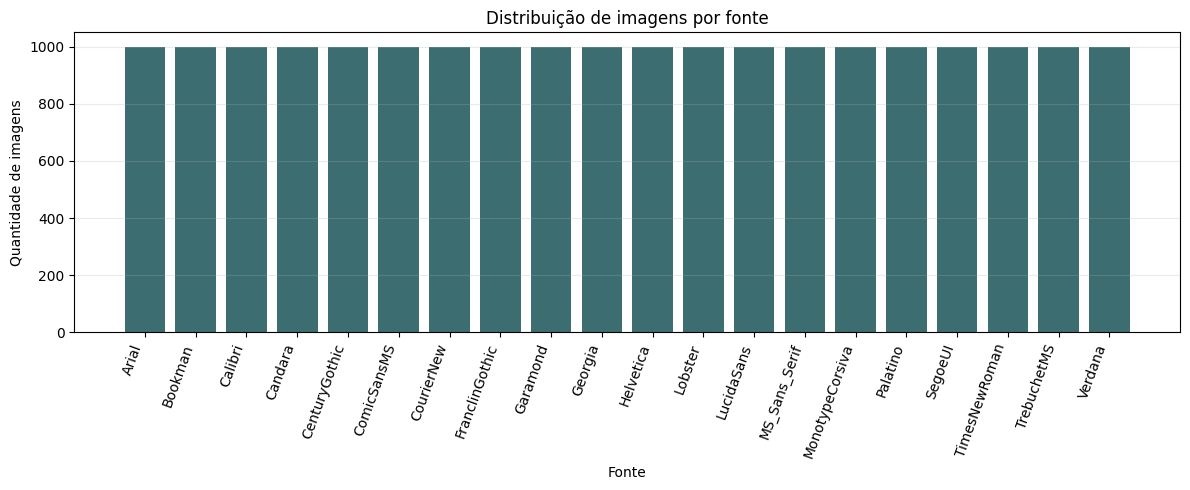

In [5]:
class_counts = metadata["Font"].value_counts().sort_index()
display(class_counts.to_frame("quantidade"))

plt.figure(figsize=(12, 5))
plt.bar(class_counts.index, class_counts.values, color="#3c6e71")
plt.title("Distribuição de imagens por fonte")
plt.xlabel("Fonte")
plt.ylabel("Quantidade de imagens")
plt.xticks(rotation=70, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
display(plt.gcf())
plt.close()

In [6]:
balanceamento = pd.DataFrame({
    "métrica": ["menor classe", "maior classe", "razão maior/menor", "desvio padrão"],
    "valor": [
        class_counts.min(),
        class_counts.max(),
        class_counts.max() / class_counts.min(),
        class_counts.std(),
    ],
})

display(balanceamento)

,métrica,valor
0,menor classe,1000.0
1,maior classe,1000.0
2,razão maior/menor,1.0
3,desvio padrão,0.0


O gráfico e a tabela mostram que todas as fontes possuem a mesma quantidade de imagens. Isso tem três consequências importantes:

- não é necessário aplicar técnicas de balanceamento, como oversampling ou undersampling;
- a acurácia se torna uma métrica mais confiável, porque cada classe contribui de forma igual para o resultado;
- o `macro F1` e o `weighted F1` tendem a ficar próximos, pois os pesos das classes são praticamente iguais.

Mesmo com classes balanceadas, ainda é necessário olhar métricas por classe. Algumas fontes podem ser mais difíceis de reconhecer por semelhança visual, não por falta de exemplos.

## 5. Tamanho das palavras

As imagens contêm palavras em inglês. O tamanho das palavras influencia a ocupação visual da imagem: palavras maiores tendem a preencher mais espaço horizontal, enquanto palavras curtas deixam mais fundo vazio.

,estatística
count,20000.0
mean,5.8652
std,1.488301
min,3.0
25%,5.0
50%,6.0
75%,7.0
max,8.0


,quantidade
TextLength,
3,1211
4,2938
5,4127
6,4256
7,3996
8,3472


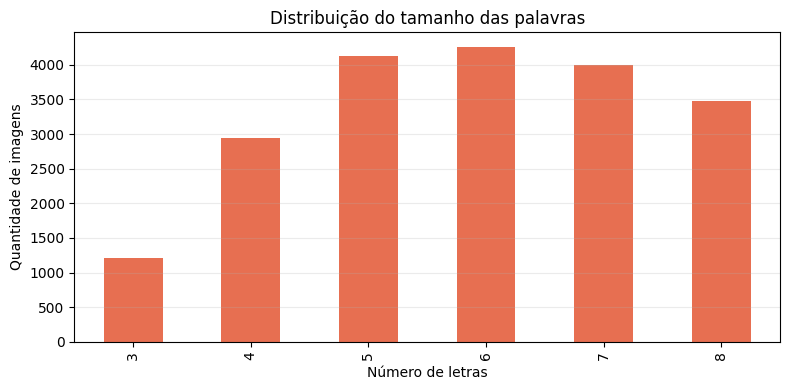

In [7]:
# Usa Int64 anulável para evitar erro caso alguma palavra seja interpretada como ausente.
metadata["TextLength"] = metadata["Text"].str.len().astype("Int64")

display(metadata["TextLength"].describe().to_frame("estatística"))
display(metadata["TextLength"].value_counts().sort_index().to_frame("quantidade"))

plt.figure(figsize=(8, 4))
metadata["TextLength"].value_counts().sort_index().plot(kind="bar", color="#e76f51")
plt.title("Distribuição do tamanho das palavras")
plt.xlabel("Número de letras")
plt.ylabel("Quantidade de imagens")
plt.grid(axis="y", alpha=0.25)
plt.tight_layout()
display(plt.gcf())
plt.close()

In [8]:
word_length_by_font = metadata.groupby("Font")["TextLength"].agg(["min", "mean", "max", "std"]).round(2)
display(word_length_by_font)

,min,mean,max,std
Font,,,,
Arial,3,5.91,8,1.5
Bookman,3,5.86,8,1.49
Calibri,3,5.88,8,1.46
Candara,3,5.73,8,1.53
CenturyGothic,3,5.89,8,1.48
ComicSansMS,3,5.88,8,1.52
CourierNew,3,5.9,8,1.51
FranclinGothic,3,5.84,8,1.5
Garamond,3,5.9,8,1.46


A faixa de 3 a 8 letras confirma a descrição do dataset. Essa variação é importante porque o modelo não deve aprender apenas o tamanho ou a posição da palavra; ele precisa aprender características da fonte.

Se uma fonte tivesse palavras sistematicamente maiores que outra, haveria risco de viés: o modelo poderia associar comprimento da palavra à classe. A tabela por fonte ajuda a verificar se essa variação está espalhada entre as classes.

Na modelagem, o redimensionamento para um tamanho fixo resolve a necessidade técnica de entrada padronizada. Porém, ele também comprime palavras maiores. Por isso, é importante escolher um tamanho que preserve detalhes visuais suficientes, como serifas e curvaturas.

## 6. Formato e resolução das imagens

A documentação informa que as imagens são preto e branco, com resolução de 200 x 50 pixels. A célula abaixo confirma essas características diretamente nos arquivos.

In [9]:
sizes = Counter()
modes = Counter()

# As imagens são pequenas; por isso é viável verificar todos os arquivos.
for path in metadata["ImagePath"]:
    with Image.open(path) as img:
        sizes[img.size] += 1
        modes[img.mode] += 1

display(pd.DataFrame(sizes.items(), columns=["resolução", "quantidade"]))
display(pd.DataFrame(modes.items(), columns=["modo", "quantidade"]))

,resolução,quantidade
0,"(200, 50)",20000


,modo,quantidade
0,RGB,20000


In [10]:
sample_paths = metadata["ImagePath"].head(100)
pixel_ranges = []

for path in sample_paths:
    with Image.open(path).convert("L") as img:
        extrema = img.getextrema()
        pixel_ranges.append({"arquivo": Path(path).name, "mínimo": extrema[0], "máximo": extrema[1]})

display(pd.DataFrame(pixel_ranges).head(10))

,arquivo,mínimo,máximo
0,file_1.png,0,255
1,file_2.png,0,255
2,file_3.png,0,255
3,file_4.png,0,255
4,file_5.png,0,255
5,file_6.png,0,255
6,file_7.png,0,255
7,file_8.png,0,255
8,file_9.png,0,255
9,file_10.png,0,255


A resolução única facilita o pipeline, porque todas as imagens já chegam com o mesmo tamanho original. Mesmo assim, o modelo usa uma versão reduzida para acelerar o treinamento.

O modo `RGB` aparece mesmo em imagens visualmente preto e branco. Por isso, o pré-processamento converte as imagens para escala de cinza. Essa conversão evita redundância entre canais e reduz a quantidade de informação de entrada.

A análise dos valores mínimo e máximo dos pixels confirma que as imagens possuem fundo claro e traços escuros. No pipeline, os pixels são invertidos para que o traço da letra vire sinal alto e o fundo vire sinal baixo, o que deixa a entrada mais intuitiva para o modelo.

## 7. Amostras visuais por classe

A visualização ajuda a perceber diferenças entre fontes com serifa, fontes sem serifa e fontes mais estilizadas. Essa etapa é essencial porque a classificação depende de padrões visuais sutis.

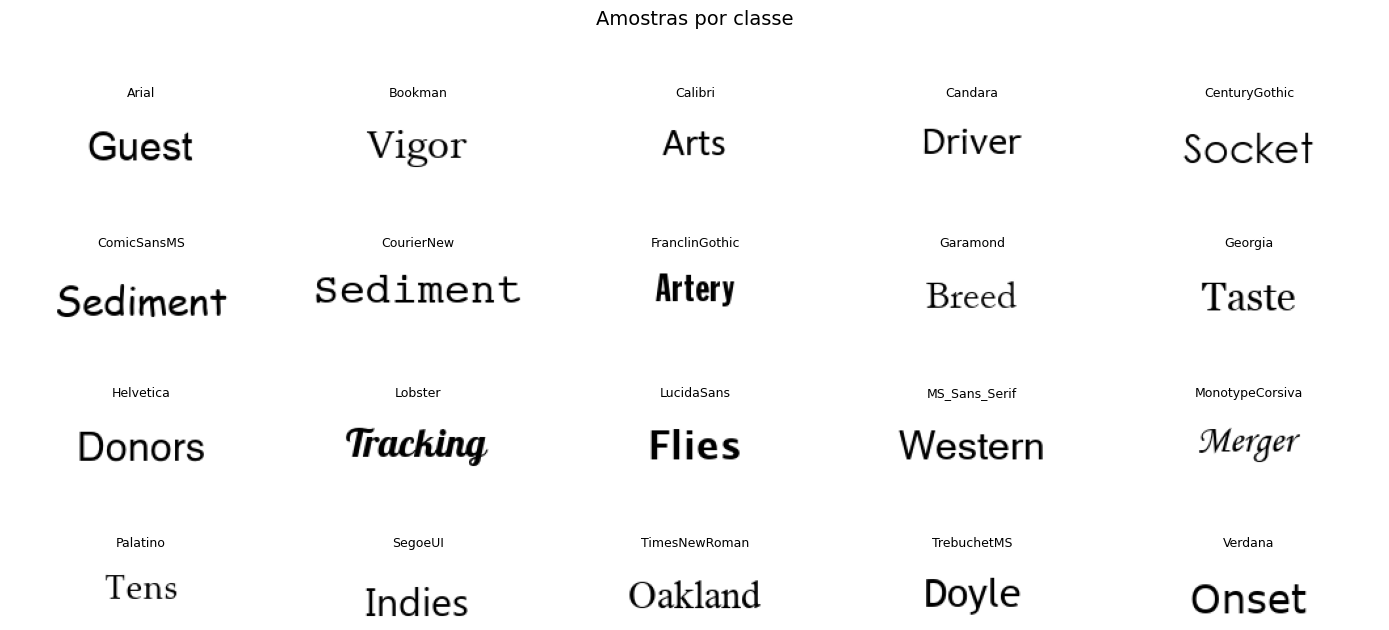

In [11]:
classes = sorted(metadata["Font"].unique())

fig, axes = plt.subplots(4, 5, figsize=(14, 7))
axes = axes.ravel()

for ax, font in zip(axes, classes):
    row = metadata[metadata["Font"] == font].iloc[0]
    with Image.open(row["ImagePath"]) as img:
        ax.imshow(img.convert("L"), cmap="gray", vmin=0, vmax=255)
    ax.set_title(font, fontsize=9)
    ax.axis("off")

fig.suptitle("Amostras por classe", fontsize=14)
plt.tight_layout()
display(fig)
plt.close(fig)

As amostras mostram que algumas classes possuem características bem marcantes. Fontes como Lobster e MonotypeCorsiva tendem a ser mais estilizadas, com formas cursivas ou ornamentais. Essas diferenças facilitam a separação pelo modelo.

Por outro lado, fontes como Arial, Helvetica, Calibri, Candara, SegoeUI e TrebuchetMS são visualmente próximas. Elas compartilham ausência de serifa e traços limpos, o que pode gerar confusões na etapa de avaliação.

Essa observação antecipa uma limitação importante: mesmo que o dataset seja balanceado e limpo, algumas classes são naturalmente mais difíceis porque a fronteira visual entre elas é sutil.

## 8. Implicações para o pré-processamento

Com base na EDA, o pipeline de modelagem deve seguir estas decisões:

- **Divisão estratificada**: manter a mesma proporção de fontes em treino, validação e teste.
- **Conversão para escala de cinza**: remover redundância do modo RGB.
- **Redimensionamento**: padronizar a entrada e reduzir custo computacional.
- **Normalização dos pixels**: colocar os valores no intervalo `[0, 1]`.
- **Inversão de intensidade**: representar o traço da fonte como sinal alto.
- **Métricas por classe**: usar matriz de confusão, precision, recall e F1 para enxergar diferenças entre fontes visualmente parecidas.

## 9. Conclusões da análise exploratória

A análise exploratória indica que o dataset está bem estruturado para um problema supervisionado de classificação de imagens. Há 20.000 imagens, 20 fontes e 1000 exemplos por classe, o que elimina a necessidade de balanceamento artificial.

A consistência dos metadados também é favorável: não foram identificados valores ausentes, nomes duplicados ou arquivos faltantes. Isso permite seguir para a modelagem sem uma etapa pesada de limpeza.

As imagens possuem resolução padronizada de 200 x 50 pixels e são visualmente preto e branco, embora estejam salvas em modo RGB. Por isso, a conversão para escala de cinza é uma decisão natural.

A principal dificuldade esperada não vem de problemas de qualidade dos dados, mas da semelhança visual entre algumas fontes. Fontes sem serifa e com proporções parecidas devem gerar mais erros do que fontes decorativas ou cursivas. Essa hipótese será verificada no notebook de modelagem por meio das métricas por classe e da matriz de confusão.

Em síntese, o dataset é balanceado, possui resolução padronizada e não apresenta problemas estruturais relevantes. Dessa forma, não foram necessárias técnicas de balanceamento de classes, sendo suficiente realizar normalização, redimensionamento e conversão das imagens para uma representação adequada aos modelos.
